In [294]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Importar configurações

In [300]:
import sys
import os
from pathlib import Path

# Encontrar o diretório scripts do projeto
current_dir = Path.cwd()
scripts_dir = current_dir / 'scripts'
if not scripts_dir.exists():
    scripts_dir = current_dir.parent / 'scripts'

sys.path.insert(0, str(scripts_dir))

from config import DOCUMENTS_DIR, RESULTS_CSV, SYMPTOMS_TXT, DIAGNOSTICS_CSV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

Carregar os dados

In [301]:
# Usar o caminho centralizado da configuração
caminho_csv = DOCUMENTS_DIR / 'triagem_risco.csv'
print(f"Procurando arquivo em: {caminho_csv}")

Procurando arquivo em: /Users/amanda/Documents/FIAP/projetos/chap01-phase02-automate-diagnostics/document/triagem_risco.csv


In [308]:
# Carregar o arquivo CSV de triagem de risco
if caminho_csv.exists():
    df = pd.read_csv(caminho_csv)
    print(f"✅ Sucesso! Arquivo encontrado em: {caminho_csv}")
    print(f"   Total de casos: {len(df)}")
    print(f"\nPrimeiras 3 linhas:")
    print(df.head(3))
else:
    print(f"❌ Erro: O arquivo não está em {caminho_csv}")
    print(f"   Arquivos em {DOCUMENTS_DIR}:")
    if DOCUMENTS_DIR.exists():
        for f in DOCUMENTS_DIR.glob('*.csv'):
            print(f"   - {f.name}")

✅ Sucesso! Arquivo encontrado em: /Users/amanda/Documents/FIAP/projetos/chap01-phase02-automate-diagnostics/document/triagem_risco.csv
   Total de casos: 30

Primeiras 3 linhas:
                                             sintoma classificacao
0  De repente senti queimação forte no peito que ...   baixo risco
1  Tenho um incômodo que vem e vai no meio do pei...   baixo risco
2  Sinto uma dor aguda nas costas entre os ombros...    alto risco


Limpeza do arquivo csv

In [309]:
df = df.dropna()
df['sintoma'] = df['sintoma'].astype(str).str.strip()
df['classificacao'] = df['classificacao'].astype(str).str.strip()

Vetorização TF-IDF

In [310]:
vectorizer = TfidfVectorizer(ngram_range=(1, 1), stop_words=None) 
X = vectorizer.fit_transform(df['sintoma'])
y = df['classificacao']

Treinamento de máquina

In [311]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Modelo Árvore de Decisão

In [312]:
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Análise do Aprendizado de Máquina

<Figure size 800x600 with 0 Axes>

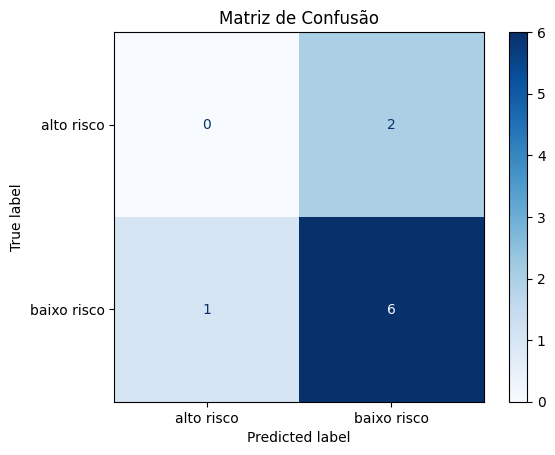

In [313]:
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap='Blues')
plt.title(f"Matriz de Confusão")
plt.show()

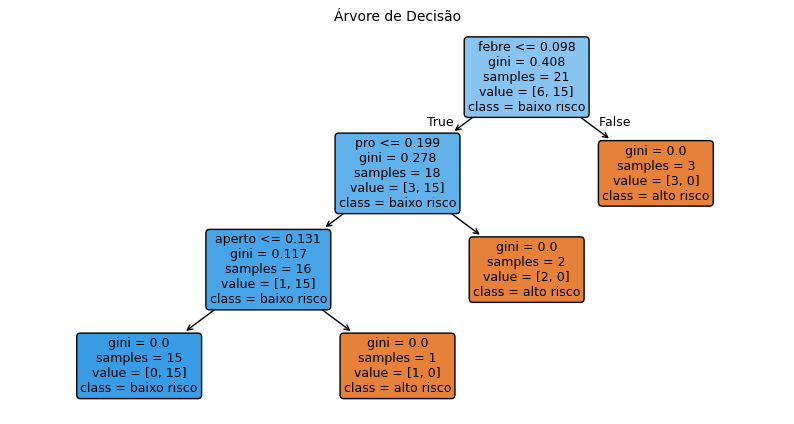

In [314]:
plt.figure(figsize=(10,5))
plot_tree(modelo, 
          feature_names=vectorizer.get_feature_names_out(), 
          class_names=list(modelo.classes_), 
          filled=True, 
          rounded=True, 
          fontsize=9)
plt.title("Árvore de Decisão", fontsize=10)
plt.show()

Acurácia do Modelo

In [ ]:
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"📊 Acurácia Final: {acuracia * 100:.2f}%")


📊 Acurácia Final: 66.67%
